In [13]:
# --- ESCAPE loop convergence: n_e and T_e at every iteration, for every equilibrium ---
# Reads ITER_SCAN_DIR/{EQUIL}/{RUN}/{EQUIL}/ne_and_Te_iter_*.npy for every equilibrium
# directory (<shot>.<time>) under ITER_SCAN_DIR - the per-iteration dumps
# profiles_loop_solve_epednn_neped_scan.py writes on every pass through the ESCAPE loop
# (n_e = 'y' on 'psi_N_ne', the new T_e it generates for the next iteration =
# 'Te_new_keV' on 'psi_N_Te_new'). One figure per equilibrium, n_e on the left and T_e
# on the right. Each line is one iteration, colour-graded blue (early) -> red (late) by
# ITERATION NUMBER, so a converged run's late (red) iterations collapse onto the
# reference while a diverging one keeps drifting away. The dashed reference curve is the
# experimental (OMFIT IDA) input profile the loop is trying to match, read directly from
# the IDA netCDF for that equilibrium (omitted, with a warning, if none is found).
# The y-axes are sized to fit every solved curve and the reference inside the window.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.ticker import MaxNLocator
import netCDF4 as nc
import numpy as np

# ------------------------------------------------------------------ user input
ITER_SCAN_DIR = Path('DIIIDSnyder_ESCAPE_noKBM_ETG05_pwfix_large')
ITER_RUN = 'neouter0_fp0'         # free-parameter combo directory within each equilibrium
PFILE_DIR = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode')
PSI_LO_ITER = 0.85                # pedestal window for both subplots
ITER_CMAP = 'coolwarm'
Y_PAD = 1.05                      # headroom above the highest curve in the window
# -----------------------------------------------------------------------------


def find_equilibria(scan_dir):
    """Every <shot>.<time> equilibrium directory directly under scan_dir, sorted."""
    return sorted(p.name for p in Path(scan_dir).iterdir()
                  if p.is_dir() and re.fullmatch(r'\d+\.\d+', p.name))


def load_escape_iters(scan_dir, equil, run):
    """All ne_and_Te_iter_*.npy dumps for one ESCAPE loop run, sorted by iteration."""
    run_dir = Path(scan_dir) / equil / run / equil
    files = sorted(run_dir.glob('ne_and_Te_iter_*.npy'),
                   key=lambda p: int(re.match(r'ne_and_Te_iter_(\d+)\.npy$', p.name).group(1)))
    return [np.load(fp, allow_pickle=True).item() for fp in files]


def reference_profiles(pfile_dir, equil):
    """Experimental (OMFIT IDA) n_e/T_e the ESCAPE loop is trying to match.

    `equil` is a <shot>.<time_ms_5digit> tag; the matching IDA netCDF is found by
    shot number and by the time window bracketing time_ms/1000 seconds.
    """
    shot, frac = equil.split('.')
    time_s = int(frac) / 1000.0
    for fp in sorted(Path(pfile_dir).glob(f'IDA_{shot}_*_*_.cdf')):
        m = re.match(rf'IDA_{shot}_([\d.]+)_([\d.]+)_\.cdf$', fp.name)
        if m and float(m.group(1)) <= time_s <= float(m.group(2)):
            break
    else:
        raise FileNotFoundError(f'no IDA netCDF for {equil} under {pfile_dir}')

    with nc.Dataset(fp) as f:
        psi = np.asarray(f.variables['psi_n'][:], dtype=float)
        ne = np.nanmean(np.ma.filled(f.variables['n_e'][:], np.nan), axis=0)
        Te_eV = np.nanmean(np.ma.filled(f.variables['T_e'][:], np.nan), axis=0)
    good = np.isfinite(psi) & np.isfinite(ne) & np.isfinite(Te_eV)
    return psi[good], ne[good], Te_eV[good] / 1e3   # Te: eV -> keV


def plot_iters(ax, iters, x_key, y_key, y_scale, psi_lo, cmap):
    """Overlay every iteration's profile, each whole curve colour-graded by ITERATION NUMBER.

    Returns the largest finite y plotted inside the window (NaN if nothing was plotted).
    """
    n = len(iters)
    cmap = plt.get_cmap(cmap)
    y_max = np.nan
    for i, it in enumerate(iters):
        x = np.asarray(it[x_key], dtype=float)
        y = np.asarray(it[y_key], dtype=float) * y_scale
        keep = x >= psi_lo
        x, y = x[keep], y[keep]
        if x.size < 2:
            continue
        order = np.argsort(x)
        x, y = x[order], y[order]
        color = cmap(i / max(n - 1, 1))
        ax.plot(x, y, '-', color=color, linewidth=1.2)
        y_max = np.nanmax([y_max, np.nanmax(y)])
    return y_max


def plot_equil(equil, iters, psi_lo=PSI_LO_ITER, cmap=ITER_CMAP,
               label_fs=15, tick_fs=12, cbar_label_fs=12, cbar_tick_fs=10, suptitle_fs=15, legend_fs=11):
    """One figure, two subplots: n_e (left) and T_e (right) at every ESCAPE iteration."""
    try:
        psi_ref, ne_ref, Te_ref_keV = reference_profiles(PFILE_DIR, equil)
    except FileNotFoundError as err:
        print(f'  warning: {err}; plotting without the reference profile')
        psi_ref = None

    fig, (ax_ne, ax_Te) = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')
    y_max = {ax_ne: plot_iters(ax_ne, iters, 'psi_N_ne', 'y', 1e-19, psi_lo, cmap),
             ax_Te: plot_iters(ax_Te, iters, 'psi_N_Te_new', 'Te_new_keV', 1.0, psi_lo, cmap)}

    if psi_ref is not None:
        ped = psi_ref >= psi_lo
        for ax, y_ref in ((ax_ne, ne_ref[ped] / 1e19), (ax_Te, Te_ref_keV[ped])):
            ax.plot(psi_ref[ped], y_ref, '--', color='red', linewidth=2,
                    label='IDA')
            y_max[ax] = np.nanmax([y_max[ax], y_ref.max()])
            ax.legend(fontsize=legend_fs, loc='lower left')

    for ax, ylabel in ((ax_ne, r'$n_e$ ($10^{19}$ m$^{-3}$)'),
                       (ax_Te, r'$T_e$ (keV)')):
        ax.set_xlim(psi_lo, 1.0)
        if np.isfinite(y_max[ax]):
            ax.set_ylim(0, Y_PAD * y_max[ax])
        ax.set_xlabel(r'$\psi_N$', fontsize=label_fs)
        ax.set_ylabel(ylabel, fontsize=label_fs)
        ax.tick_params(axis='both', labelsize=tick_fs)
        ax.tick_params(axis='x', pad=8)   # keep x tick labels clear of the y ones at the corner

    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(0, max(len(iters) - 1, 1)))
    cbar = fig.colorbar(sm, ax=[ax_ne, ax_Te], pad=0.01)
    cbar.set_label('ESCAPE iteration', fontsize=cbar_label_fs)
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    cbar.ax.tick_params(labelsize=cbar_tick_fs)
    # fig.suptitle(f'{equil} ({len(iters)} ESCAPE iterations)', fontsize=suptitle_fs)
    fig.suptitle(f'{equil}', fontsize=suptitle_fs)
    plt.show()


equils = find_equilibria(ITER_SCAN_DIR)
print(f'[{ITER_SCAN_DIR}] {len(equils)} equilibria found')


[DIIIDSnyder_ESCAPE_noKBM_ETG05_pwfix_large] 4 equilibria found


In [ ]:
# ------------------------------------------------------------------ font sizes
LABEL_FS = 24          # axes labels
TICK_FS = 22           # axes tick labels
CBAR_LABEL_FS = 24     # colorbar label
CBAR_TICK_FS = 22      # colorbar tick labels
SUPTITLE_FS = 22       # figure suptitle
LEGEND_FS = 18         # legend
# -----------------------------------------------------------------------------

iters_by_equil = {}
i=0
for equil in equils:
    if i==7 or i==8:
        iters = load_escape_iters(ITER_SCAN_DIR, equil, ITER_RUN)
        print(f'{equil}/{ITER_RUN}: {len(iters)} ESCAPE loop iterations found')
        if not iters:
            continue
        iters_by_equil[equil] = iters
        plot_equil(equil, iters, label_fs=LABEL_FS, tick_fs=TICK_FS,
                   cbar_label_fs=CBAR_LABEL_FS, cbar_tick_fs=CBAR_TICK_FS,
                   suptitle_fs=SUPTITLE_FS, legend_fs=LEGEND_FS)
    if i == 11:
        break
    i+=1

# The convergence-tolerance cell below plots a single run: default it to the first one.
ITER_EQUIL = next(iter(iters_by_equil))
iters = iters_by_equil[ITER_EQUIL]


125729.03589/neouter0_fp0: 199 iterations with loop_tol
128413.04088/neouter0_fp0: 199 iterations with loop_tol
128572.03809/neouter0_fp0: 199 iterations with loop_tol
128578.03658/neouter0_fp0: 199 iterations with loop_tol


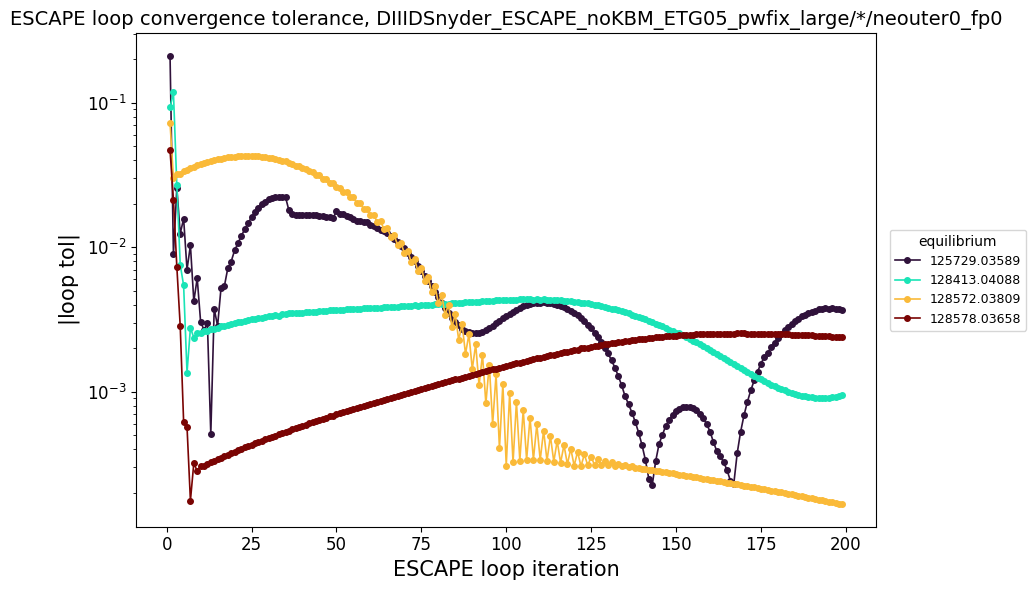

In [14]:
# --- ESCAPE loop convergence tolerance vs iteration, one line per equilibrium ---
# Stand-alone: needs nothing from the cells above.
# `loop_tol` is the normalized change in pedestal height + width between this
# iteration and the previous one (see profiles_loop_solve_epednn_neped_scan.py);
# the loop stops once abs(loop_tol) < eped_tol_max. It is stored on every dump
# from iteration 1 onward (iteration 0 has nothing prior to compare against).
# Reads TOL_SCAN_DIR/{EQUIL}/{TOL_RUN}/{EQUIL}/ne_and_Te_iter_*.npy for every
# <shot>.<time> equilibrium directory under TOL_SCAN_DIR, one line per equilibrium.
# Log-scale y-axis since loop_tol spans several orders of magnitude.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# ------------------------------------------------------------------ user input
TOL_SCAN_DIR = Path('DIIIDSnyder_ESCAPE_noKBM_ETG05_pwfix_large')
TOL_RUN = 'neouter0_fp0'   # free-parameter combo directory within each equilibrium
TOL_CMAP = 'turbo'         # equilibria are colour-graded along this map
# -----------------------------------------------------------------------------


def load_loop_tols(scan_dir, equil, run):
    """(iteration, loop_tol) for every ne_and_Te_iter_*.npy dump that stores loop_tol."""
    run_dir = Path(scan_dir) / equil / run / equil
    tols = []
    for fp in run_dir.glob('ne_and_Te_iter_*.npy'):
        m = re.match(r'ne_and_Te_iter_(\d+)\.npy$', fp.name)
        if not m:
            continue
        tol = np.load(fp, allow_pickle=True).item().get('loop_tol')
        if tol is not None:
            tols.append((int(m.group(1)), float(tol)))
    return sorted(tols)


tol_equils = sorted(p.name for p in TOL_SCAN_DIR.iterdir()
                    if p.is_dir() and re.fullmatch(r'\d+\.\d+', p.name))

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap(TOL_CMAP)
n_equil = len(tol_equils)
for k, equil in enumerate(tol_equils):
    tols = load_loop_tols(TOL_SCAN_DIR, equil, TOL_RUN)
    print(f'{equil}/{TOL_RUN}: {len(tols)} iterations with loop_tol')
    if not tols:
        continue
    tol_iters, tol_vals = zip(*tols)
    ax.plot(tol_iters, np.abs(tol_vals), 'o-', markersize=4, linewidth=1.2,
            color=cmap(k / max(n_equil - 1, 1)), label=equil)

ax.set_yscale('log')
ax.set_xlabel('ESCAPE loop iteration', fontsize=15)
ax.set_ylabel(r'$|{\rm loop\ tol}|$', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.set_title(f'ESCAPE loop convergence tolerance, {TOL_SCAN_DIR}/*/{TOL_RUN}',
             fontsize=14)
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.01, 0.5),
          title='equilibrium', title_fontsize=10)
plt.tight_layout()
plt.show()


[DIIIDSnyder_ESCAPE_noKBM_ETG05_outer] successful 243, failed 59, pending 0, outside the solved domain 0
  fixed: C_KBM = 0, De_chie_etg = 0.5, alpha_crit = 0.01, nFC_x0 = 1e+15, ncx_x0_ratio = 15
  243 equilibria: 243 runs, median ESCAPE/experiment - 1 = -76.6%


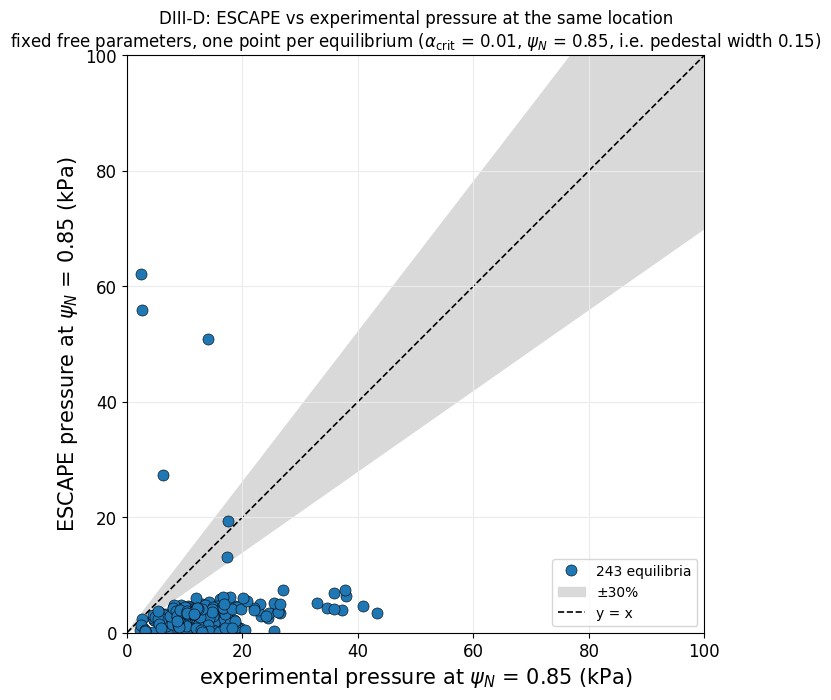

In [5]:
# --- Full scan over all equilibria: ESCAPE vs experimental pressure at psi_N = PSI_EXP ---
# Reads SCAN_DIR/{EQUIL}/neouter{j}_fp{i}/out_dict.npy (failed.npy on failure; a run dir
# with neither is still in flight and is counted as pending). One point per equilibrium
# per scanned free-parameter value, coloured by that value.
# Both axes are the SAME quantity at the SAME radius, so the dashed y = x line means
# agreement:
#   x  experimental  out_dict['profiles']        p = 2*ne*Te ('ne' [m^-3] on 'psi_N_ne',
#                                                'Te' [keV] on 'psi_N_Te')
#   y  ESCAPE        out_dict['profiles_solved'] p = 2*ne*Te ('y' [m^-3] on 'psi_N_ne',
#                                                'T_e' [eV] on 'psi_N')
# The p = 2*ne*Te closure (Ti = Te, ni = ne) is calc_pressure_profile's for these IDA
# files, which carry no main-ion channels. psi_N = 0.85 is the solver's inner boundary
# psi_N_inner, so PSI_EXP < 0.85 has no solved profile to read and those runs are
# reported as "outside the solved domain" and dropped.
# PARAM_KEY = None auto-detects which free parameter the scan varies; a scan that holds
# all of them fixed (as DIIIDSnyder_ESCAPE_nofpscan does) is drawn as a single series.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# ------------------------------------------------------------------ user input
SCAN_DIR = Path('DIIIDSnyder_ESCAPE_noKBM_ETG05_outer')
PSI_EXP = 0.85            # psi_N at which BOTH pressures are read
PARAM_KEY = None          # free parameter on the colour axis; None = auto-detect
AGREE_BAND = 0.30         # +/- fractional band shaded around the y = x agreement line
# -----------------------------------------------------------------------------

EV_TO_J = 1.602176634e-19
PARAM_COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
                'tab:purple', 'tab:brown']
PARAM_LABELS = {
    'De_chie_etg':  r'$D_{e}\chi_{e}^{\mathrm{ETG}}$',
    'C_KBM':        r'$C_{\mathrm{KBM}}$',
    'alpha_crit':   r'$\alpha_{\mathrm{crit}}$',
    'nFC_x0':       r'$n_{\mathrm{FC}}(0)$',
    'ncx_x0_ratio': r'$n_{\mathrm{CX}}(0)/n_{\mathrm{FC}}(0)$',
}


def experimental_p_at(profiles, psi_N):
    """Input-profile thermal pressure [Pa] at psi_N, from a stored `profiles` dict.

    Mirrors calc_pressure_profile for the DIII-D OMFIT IDA layout scan_SCfp_ESCAPE.py
    saves (psi_N_ne / ne [m^-3], psi_N_Te / Te [keV], no Ti or ni): p = 2 * ne * Te.
    """
    psi = np.asarray(profiles['psi_N_ne'], dtype=float)
    ne = np.asarray(profiles['ne'], dtype=float)              # m^-3, on psi_N_ne
    psi_Te = np.asarray(profiles['psi_N_Te'], dtype=float)
    Te_keV = np.asarray(profiles['Te'], dtype=float)          # keV, on psi_N_Te

    # Te onto the ne grid, then p on that grid, and only then interpolate p - the
    # same order calc_pressure_profile uses.
    order = np.argsort(psi_Te)
    Te_keV = np.interp(psi, psi_Te[order], Te_keV[order])
    p = 2.0 * ne * Te_keV * 1e3 * EV_TO_J                     # Pa

    order = np.argsort(psi)
    return float(np.interp(psi_N, psi[order], p[order]))


def escape_p_at(sol, psi_N):
    """Solved-profile ESCAPE thermal pressure [Pa] at psi_N, same p = 2*ne*Te closure.

    NaN if psi_N is outside the solved n_e domain, which starts at psi_N_inner = 0.85.
    """
    psi_ne = np.asarray(sol['psi_N_ne'], dtype=float)
    ne = np.asarray(sol['y'], dtype=float)                    # m^-3
    psi_Te = np.asarray(sol['psi_N'], dtype=float)
    Te_eV = np.asarray(sol['T_e'], dtype=float)               # eV

    if psi_N < psi_ne.min() or psi_N > psi_ne.max():
        return np.nan

    order = np.argsort(psi_Te)
    Te_on_ne = np.interp(psi_ne, psi_Te[order], Te_eV[order])
    p = 2.0 * ne * Te_on_ne * EV_TO_J                         # Pa

    order = np.argsort(psi_ne)
    return float(np.interp(psi_N, psi_ne[order], p[order]))


def load_full_scan(scan_dir, psi_exp=PSI_EXP):
    """Every finished run under scan_dir, with both pressures read at psi_exp."""
    scan_dir = Path(scan_dir)
    runs, failed, pending, outside = [], [], [], []
    for equil_dir in sorted(p for p in scan_dir.iterdir() if p.is_dir()):
        for run_dir in sorted(equil_dir.glob('neouter*_fp*'),
                              key=lambda p: tuple(int(v) for v in
                                                  re.match(r'neouter(\d+)_fp(\d+)$',
                                                           p.name).groups())):
            name = f'{equil_dir.name}/{run_dir.name}'
            out_fp = run_dir / 'out_dict.npy'
            if not out_fp.exists():
                (failed if (run_dir / 'failed.npy').exists() else pending).append(name)
                continue
            d = np.load(out_fp, allow_pickle=True).item()
            p_escape = escape_p_at(d['profiles_solved'], psi_exp)
            if not np.isfinite(p_escape):
                outside.append(name)
                continue
            runs.append({
                'equil':       equil_dir.name,
                'run':         run_dir.name,
                'free_params': {k: float(v) for k, v in d['free_params'].items()},
                'p_escape':    p_escape / 1e3,                          # Pa -> kPa
                'p_exp':       experimental_p_at(d['profiles'], psi_exp) / 1e3,
                'ped_h_eped':  float(d['ESCAPE_ped_h']) * 1e3,          # MPa -> kPa
                'ped_wid':     float(d['ESCAPE_ped_wid']),
            })
    return runs, failed, pending, outside


runs, failed, pending, outside = load_full_scan(SCAN_DIR)
print(f'[{SCAN_DIR}] successful {len(runs)}, failed {len(failed)}, '
      f'pending {len(pending)}, outside the solved domain {len(outside)}')
if not runs:
    raise SystemExit('no usable runs, nothing to plot')

# Which free parameter actually varies across the scan.
all_keys = sorted(runs[0]['free_params'])
varying = [k for k in all_keys if len({r['free_params'][k] for r in runs}) > 1]
param_key = PARAM_KEY if PARAM_KEY is not None else (varying[0] if varying else None)
if len(varying) > 1:
    print(f'  more than one free parameter varies ({", ".join(varying)}); '
          f'colouring by {param_key} only')
fixed = {k: runs[0]['free_params'][k] for k in all_keys
         if k != param_key and len({r['free_params'][k] for r in runs}) == 1}
print('  fixed: ' + ', '.join(f'{k} = {v:g}' for k, v in fixed.items()))

param_vals = sorted({r['free_params'][param_key] for r in runs}) if param_key else [None]
param_label = PARAM_LABELS.get(param_key, param_key)
param_color = {v: PARAM_COLORS[k % len(PARAM_COLORS)] for k, v in enumerate(param_vals)}

fig, ax = plt.subplots(figsize=(8, 7.5))
for v in param_vals:
    g = runs if v is None else [r for r in runs
                                if np.isclose(r['free_params'][param_key], v)]
    if not g:
        continue
    p_escape = np.array([r['p_escape'] for r in g])
    p_exp = np.array([r['p_exp'] for r in g])
    label = (f'{len(g)} equilibria' if v is None
             else rf'{param_label} = {v:g}')
    ax.plot(p_exp, p_escape, 'o', color=param_color[v], markersize=8, linestyle='none',
            markeredgecolor='black', markeredgewidth=0.4, label=label)
    rel = np.median(p_escape / p_exp - 1.0) * 100
    print(f'  {label}: {len(g)} runs, median ESCAPE/experiment - 1 = {rel:+.1f}%')

# y = x: at this psi_N both axes are the same quantity, so this is agreement.
lim_hi = 1.05 * max(max(r['p_escape'] for r in runs), max(r['p_exp'] for r in runs))
x_line = np.array([0, lim_hi])
ax.fill_between(x_line, (1 - AGREE_BAND) * x_line, (1 + AGREE_BAND) * x_line,
                color='0.85', zorder=0, label=f'±{AGREE_BAND:.0%}')
ax.plot(x_line, x_line, 'k--', linewidth=1.2, zorder=0, label='y = x')

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(rf'experimental pressure at $\psi_N$ = {PSI_EXP:g} (kPa)', fontsize=15)
ax.set_ylabel(rf'ESCAPE pressure at $\psi_N$ = {PSI_EXP:g} (kPa)', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.grid(color='0.92', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(fontsize=10, loc='best')
scan_title = (f'{param_label} scan' if param_key else 'fixed free parameters')
alpha_note = (rf'$\alpha_{{\mathrm{{crit}}}}$ = {fixed["alpha_crit"]:g}, '
              if 'alpha_crit' in fixed else '')
ax.set_title('DIII-D: ESCAPE vs experimental pressure at the same location\n'
             f'{scan_title}, one point per equilibrium ('
             + alpha_note
             + rf'$\psi_N$ = {PSI_EXP:g}, i.e. pedestal width {1 - PSI_EXP:g})',
             fontsize=12)
# plt.tight_layout()
plt.show()


[DIIIDSnyder_ESCAPE_noKBM_stiff_ETG005] successful 302, failed 0, pending 0, outside the solved domain 0
  fixed: C_KBM = 0, De_chie_etg = 0.05, alpha_crit = 0.01, nFC_x0 = 1e+15, ncx_x0_ratio = 15
  $n_e$, 302 equilibria: 302 runs, median ESCAPE/experiment - 1 = +71.0%
  $T_e$, 302 equilibria: 302 runs, median ESCAPE/experiment - 1 = +4.8%


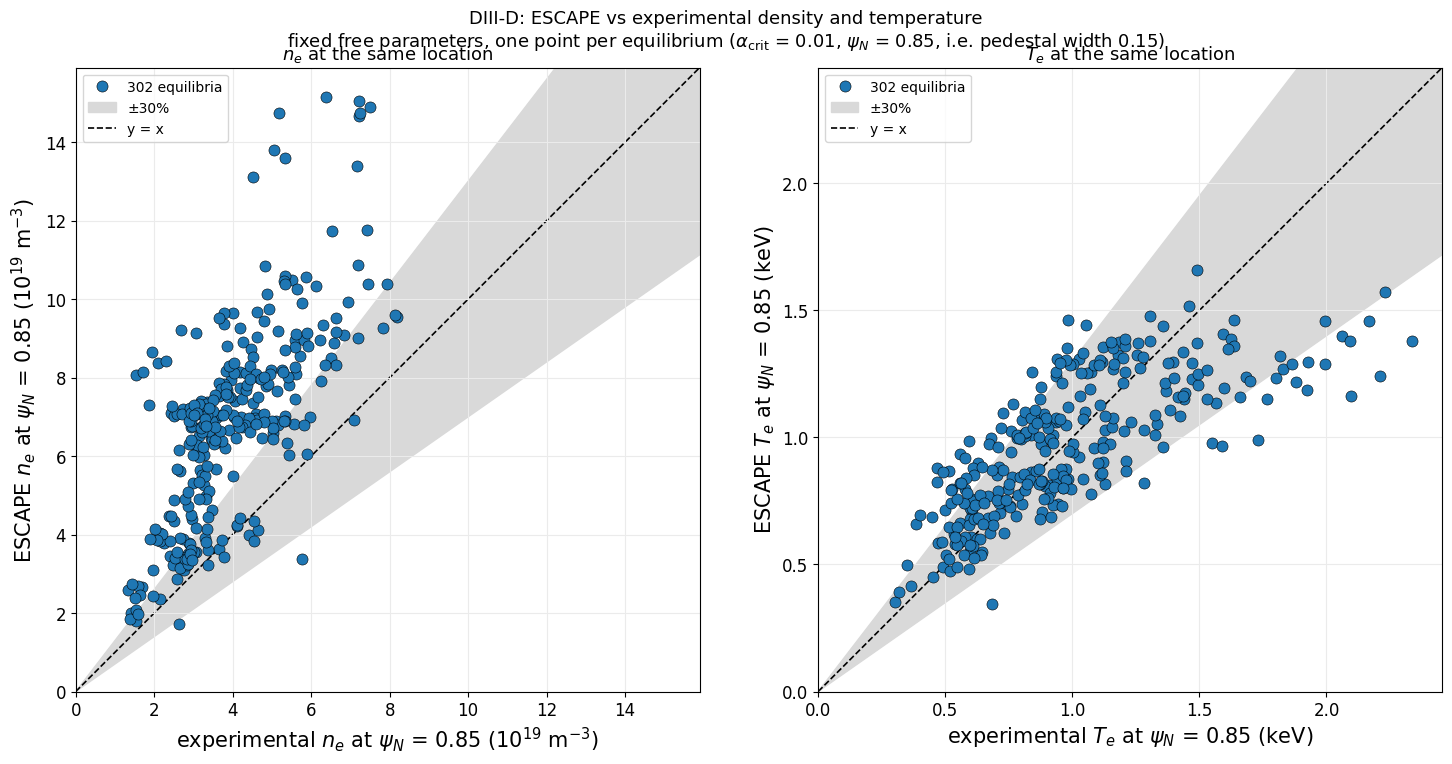

In [3]:
# --- Full scan over all equilibria: ESCAPE vs experimental n_e and T_e at psi_N = PSI_NT ---
# Same runs, same reader layout and same psi_N as the pressure cell above, but the two
# factors of p = 2*ne*Te are compared separately: n_e on the left, T_e on the right.
# Reads SCAN_DIR/{EQUIL}/neouter{j}_fp{i}/out_dict.npy (failed.npy on failure; a run dir
# with neither is still in flight and is counted as pending). One point per equilibrium
# per scanned free-parameter value, coloured by that value.
# Both axes of each subplot are the SAME quantity at the SAME radius, so the dashed
# y = x line means agreement:
#   x  experimental  out_dict['profiles']        'ne' [m^-3] on 'psi_N_ne',
#                                                'Te' [keV]  on 'psi_N_Te'
#   y  ESCAPE        out_dict['profiles_solved'] 'y'   [m^-3] on 'psi_N_ne',
#                                                'T_e' [eV]   on 'psi_N'
# psi_N = 0.85 is the solver's inner boundary psi_N_inner, so PSI_NT < 0.85 has no solved
# profile to read and those runs are reported as "outside the solved domain" and dropped.
# PARAM_KEY_NT = None auto-detects which free parameter the scan varies; a scan that
# holds all of them fixed is drawn as a single series.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# ------------------------------------------------------------------ user input
SCAN_DIR_NT = Path('DIIIDSnyder_ESCAPE_noKBM_stiff_ETG005')
PSI_NT = 0.85             # psi_N at which BOTH n_e and T_e are read
PARAM_KEY_NT = None       # free parameter on the colour axis; None = auto-detect
AGREE_BAND_NT = 0.30      # +/- fractional band shaded around the y = x agreement line
# -----------------------------------------------------------------------------


def profile_at(psi_grid, values, psi_N):
    """`values` interpolated onto psi_N; NaN outside the grid's domain."""
    psi = np.asarray(psi_grid, dtype=float)
    y = np.asarray(values, dtype=float)
    if psi_N < psi.min() or psi_N > psi.max():
        return np.nan
    order = np.argsort(psi)
    return float(np.interp(psi_N, psi[order], y[order]))


def load_scan_nT(scan_dir, psi_nt=PSI_NT):
    """Every finished run under scan_dir, with n_e and T_e read at psi_nt.

    n_e comes back in 10^19 m^-3 and T_e in keV for both the experimental and the
    ESCAPE side (the solved T_e is stored in eV, the experimental one in keV).
    """
    scan_dir = Path(scan_dir)
    runs, failed, pending, outside = [], [], [], []
    for equil_dir in sorted(p for p in scan_dir.iterdir() if p.is_dir()):
        for run_dir in sorted(equil_dir.glob('neouter*_fp*'),
                              key=lambda p: tuple(int(v) for v in
                                                  re.match(r'neouter(\d+)_fp(\d+)$',
                                                           p.name).groups())):
            name = f'{equil_dir.name}/{run_dir.name}'
            out_fp = run_dir / 'out_dict.npy'
            if not out_fp.exists():
                (failed if (run_dir / 'failed.npy').exists() else pending).append(name)
                continue
            d = np.load(out_fp, allow_pickle=True).item()
            exp, sol = d['profiles'], d['profiles_solved']
            ne_escape = profile_at(sol['psi_N_ne'], sol['y'], psi_nt) / 1e19
            Te_escape = profile_at(sol['psi_N'], sol['T_e'], psi_nt) / 1e3   # eV -> keV
            if not (np.isfinite(ne_escape) and np.isfinite(Te_escape)):
                outside.append(name)
                continue
            runs.append({
                'equil':       equil_dir.name,
                'run':         run_dir.name,
                'free_params': {k: float(v) for k, v in d['free_params'].items()},
                'ne_escape':   ne_escape,
                'Te_escape':   Te_escape,
                'ne_exp':      profile_at(exp['psi_N_ne'], exp['ne'], psi_nt) / 1e19,
                'Te_exp':      profile_at(exp['psi_N_Te'], exp['Te'], psi_nt),  # keV
            })
    return runs, failed, pending, outside


runs_nt, failed_nt, pending_nt, outside_nt = load_scan_nT(SCAN_DIR_NT)
print(f'[{SCAN_DIR_NT}] successful {len(runs_nt)}, failed {len(failed_nt)}, '
      f'pending {len(pending_nt)}, outside the solved domain {len(outside_nt)}')
if not runs_nt:
    raise SystemExit('no usable runs, nothing to plot')

# Which free parameter actually varies across the scan.
all_keys_nt = sorted(runs_nt[0]['free_params'])
varying_nt = [k for k in all_keys_nt if len({r['free_params'][k] for r in runs_nt}) > 1]
param_key_nt = (PARAM_KEY_NT if PARAM_KEY_NT is not None
                else (varying_nt[0] if varying_nt else None))
if len(varying_nt) > 1:
    print(f'  more than one free parameter varies ({", ".join(varying_nt)}); '
          f'colouring by {param_key_nt} only')
fixed_nt = {k: runs_nt[0]['free_params'][k] for k in all_keys_nt
            if k != param_key_nt and len({r['free_params'][k] for r in runs_nt}) == 1}
print('  fixed: ' + ', '.join(f'{k} = {v:g}' for k, v in fixed_nt.items()))

param_vals_nt = (sorted({r['free_params'][param_key_nt] for r in runs_nt})
                 if param_key_nt else [None])
param_label_nt = PARAM_LABELS.get(param_key_nt, param_key_nt)
param_color_nt = {v: PARAM_COLORS[k % len(PARAM_COLORS)]
                  for k, v in enumerate(param_vals_nt)}

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
panels = (
    (axes[0], 'ne', r'$n_e$', r'$n_e$ at $\psi_N$ = %g ($10^{19}$ m$^{-3}$)' % PSI_NT),
    (axes[1], 'Te', r'$T_e$', r'$T_e$ at $\psi_N$ = %g (keV)' % PSI_NT),
)

for ax, key, name, axis_label in panels:
    for v in param_vals_nt:
        g = runs_nt if v is None else [r for r in runs_nt
                                       if np.isclose(r['free_params'][param_key_nt], v)]
        if not g:
            continue
        y = np.array([r[f'{key}_escape'] for r in g])
        x = np.array([r[f'{key}_exp'] for r in g])
        label = (f'{len(g)} equilibria' if v is None
                 else rf'{param_label_nt} = {v:g}')
        ax.plot(x, y, 'o', color=param_color_nt[v], markersize=8, linestyle='none',
                markeredgecolor='black', markeredgewidth=0.4, label=label)
        rel = np.median(y / x - 1.0) * 100
        print(f'  {name}, {label}: {len(g)} runs, '
              f'median ESCAPE/experiment - 1 = {rel:+.1f}%')

    # y = x: at this psi_N both axes are the same quantity, so this is agreement.
    lim_hi = 1.05 * max(max(r[f'{key}_escape'] for r in runs_nt),
                        max(r[f'{key}_exp'] for r in runs_nt))
    x_line = np.array([0, lim_hi])
    ax.fill_between(x_line, (1 - AGREE_BAND_NT) * x_line, (1 + AGREE_BAND_NT) * x_line,
                    color='0.85', zorder=0, label=f'±{AGREE_BAND_NT:.0%}')
    ax.plot(x_line, x_line, 'k--', linewidth=1.2, zorder=0, label='y = x')

    ax.set_xlim(0, lim_hi)
    ax.set_ylim(0, lim_hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f'experimental {axis_label}', fontsize=15)
    ax.set_ylabel(f'ESCAPE {axis_label}', fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(color='0.92', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(fontsize=10, loc='best')
    ax.set_title(f'{name} at the same location', fontsize=13)

scan_title_nt = (f'{param_label_nt} scan' if param_key_nt else 'fixed free parameters')
alpha_note_nt = (rf'$\alpha_{{\mathrm{{crit}}}}$ = {fixed_nt["alpha_crit"]:g}, '
                 if 'alpha_crit' in fixed_nt else '')
fig.suptitle('DIII-D: ESCAPE vs experimental density and temperature\n'
             f'{scan_title_nt}, one point per equilibrium ('
             + alpha_note_nt
             + rf'$\psi_N$ = {PSI_NT:g}, i.e. pedestal width {1 - PSI_NT:g})',
             fontsize=13)
plt.tight_layout()
plt.show()
